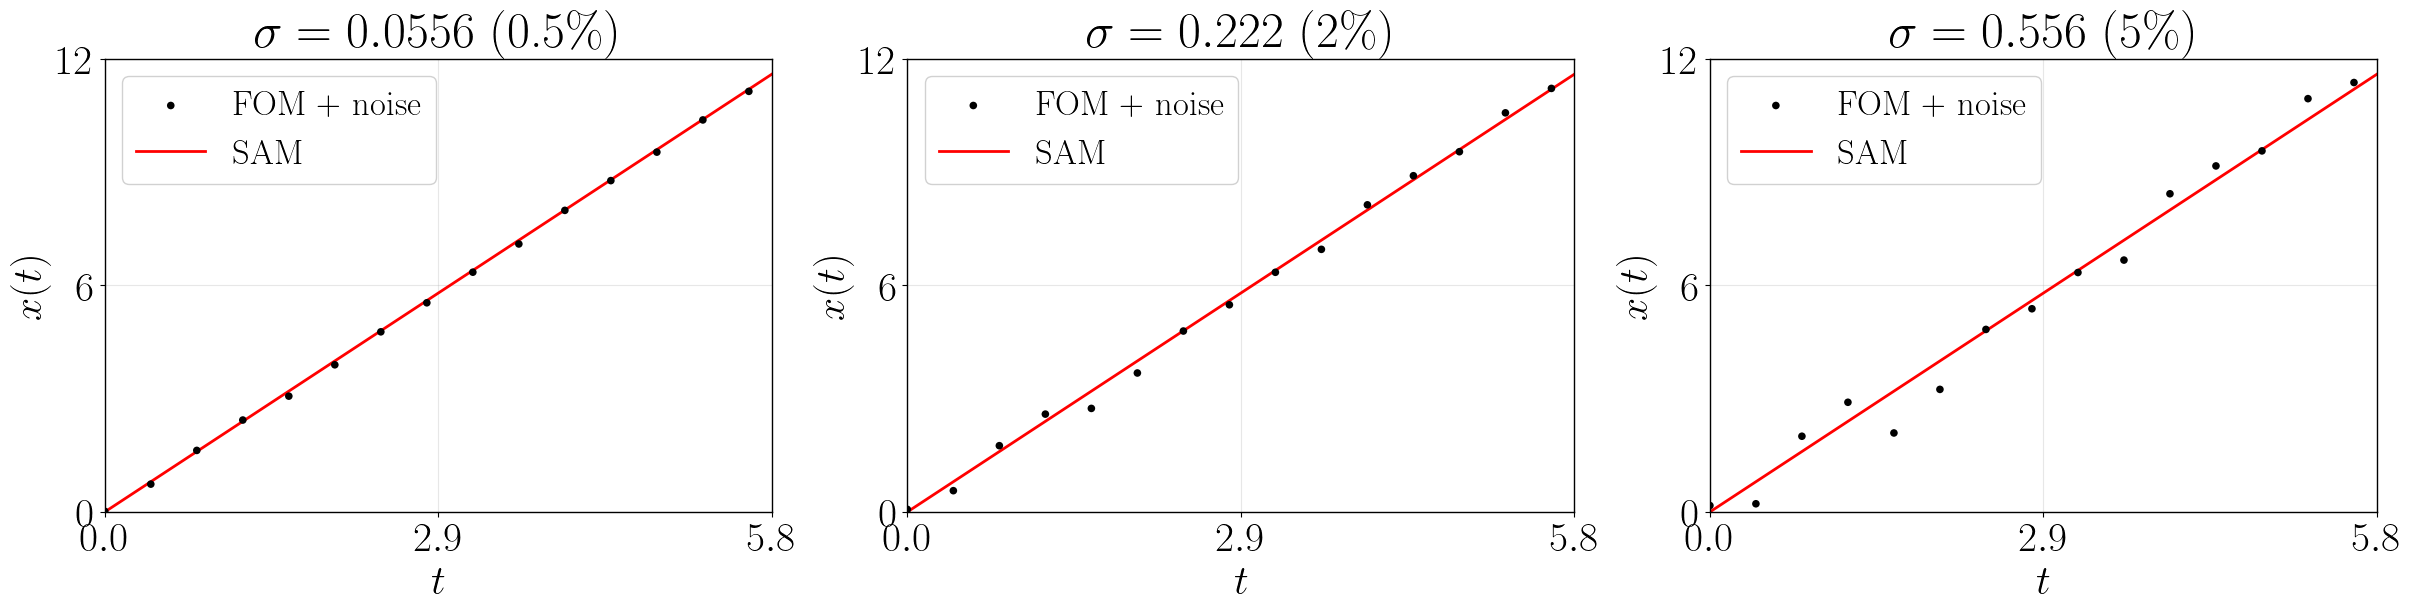

Saved: C:\Users\paraj\Documents\particle_inference_test\plots\newtonian_noise\newtonian_noise_percent_fixed_axes.pdf


In [7]:
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib

# Interactive display in Jupyter; non-interactive backend for scripts.
try:
    from IPython import get_ipython

    IPYTHON = get_ipython()
    IN_NOTEBOOK = IPYTHON is not None
except Exception:
    IPYTHON = None
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    IPYTHON.run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
ROOT = Path(r"C:\Users\paraj\Documents\particle_inference_test")

DATA_FILE = (
    ROOT
    / "data"
    / "newtonian"
    / "unbounded"
    / "delta-100-0.txt"
)

OUT_DIR = ROOT / "plots" / "newtonian_noise"


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------
DEFAULT_PERCENTS = (0.5, 2.0, 5.0)

FORCE = 12.0 * np.pi
ETA_TRUE = 1.0
RADIUS = 1.0

SEED = 42
THIN_FACTOR = 2

XLIM = (0.0, 5.8)
YLIM = (0.0, 12.0)

XTICKS = np.linspace(*XLIM, 3)
YTICKS = np.linspace(*YLIM, 3)


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 25,
    "lines.linewidth": 2,
    "axes.linewidth": 1,
})


# ---------------------------------------------------------------------
# Data and model
# ---------------------------------------------------------------------
def load_data() -> tuple[np.ndarray, np.ndarray]:
    if not DATA_FILE.is_file():
        raise FileNotFoundError(f"Data file not found:\n{DATA_FILE}")

    t, x = np.loadtxt(
        DATA_FILE,
        usecols=(0, 1),
    )[::THIN_FACTOR].T

    return t, x


def reduced_model(t: np.ndarray) -> np.ndarray:
    mobility = 1.0 / (6.0 * np.pi * ETA_TRUE * RADIUS)
    return mobility * FORCE * t


def add_noise(
    x: np.ndarray,
    percent: float,
) -> tuple[np.ndarray, float]:
    sigma = percent / 100.0 * np.max(np.abs(x))
    rng = np.random.default_rng(SEED)

    return x + rng.normal(0.0, sigma, x.size), sigma


# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------
def plot_panel(
    ax: plt.Axes,
    t: np.ndarray,
    x_clean: np.ndarray,
    percent: float,
) -> None:
    x_noisy, sigma = add_noise(x_clean, percent)
    t_model = np.linspace(*XLIM, 500)

    ax.scatter(
        t,
        x_noisy,
        s=30,
        color="black",
        edgecolors="none",
        label="FOM + noise",
        zorder=3,
    )

    ax.plot(
        t_model,
        reduced_model(t_model),
        color="red",
        label="SAM",
        zorder=2,
    )

    ax.set(
        xlabel=r"$t$",
        ylabel=r"$x(t)$",
        title=rf"$\sigma={sigma:.3g}$ ({percent:g}\%)",
        xlim=XLIM,
        ylim=YLIM,
    )

    ax.set_xticks(XTICKS)
    ax.set_yticks(YTICKS)
    ax.grid(alpha=0.3)
    ax.legend(framealpha=0.9)


def make_plot(percents: tuple[float, ...]) -> Path:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    t, x_clean = load_data()

    fig, axes = plt.subplots(
        1,
        len(percents),
        figsize=(8 * len(percents), 6),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, percent in zip(axes, percents):
        plot_panel(ax, t, x_clean, percent)

    output = OUT_DIR / "newtonian_noise_percent_fixed_axes.pdf"
    fig.savefig(output, bbox_inches="tight")

    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)

    return output


# ---------------------------------------------------------------------
# Command-line arguments
# ---------------------------------------------------------------------
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Plot noisy Newtonian FOM data against the SAM."
    )

    parser.add_argument(
        "--percents",
        nargs="+",
        type=float,
        default=DEFAULT_PERCENTS,
        help="Noise percentages, for example: 0.5 2 5",
    )

    args, _ = parser.parse_known_args()
    return args


def main() -> None:
    args = parse_args()
    PERCENTS = (0.5, 2.0, 5.0)
    output = make_plot(PERCENTS)
    print(f"Saved: {output}")


if __name__ == "__main__":
    main()